In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

In [3]:
# -------------------- LOAD DATA --------------------
df = pd.read_csv("Student_Performance.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1               91.0  
1                                 2               65.0  
2                                 2               45.0  
3                                 2               36.0  
4                                 5               66.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------              

In [4]:
# Convert Yes / No into 1 / 0
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({
    "Yes": 1,
    "No": 0
})

# Optional rename for ease
df.rename(columns={
    "Hours Studied": "hours",
    "Previous Scores": "previous",
    "Extracurricular Activities": "activities",
    "Sleep Hours": "sleep",
    "Sample Question Papers Practiced": "papers",
    "Performance Index": "performance"
}, inplace=True)

print(df.head())

   hours  previous  activities  sleep  papers  performance
0      7        99           1      9       1         91.0
1      4        82           0      4       2         65.0
2      8        51           1      7       2         45.0
3      5        52           1      5       2         36.0
4      7        75           0      8       5         66.0


In [5]:
X = df.drop("performance", axis=1)
y = df["performance"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred_linear = linear_model.predict(X_test)

In [9]:
print("MULTIPLE LINEAR REGRESSION")

print("R2 Score :", r2_score(y_test, y_pred_linear))
print("MSE      :", mean_squared_error(y_test, y_pred_linear))
print("RMSE     :", sqrt(mean_squared_error(y_test, y_pred_linear)))

MULTIPLE LINEAR REGRESSION
R2 Score : 0.9889832909573145
MSE      : 4.082628398521857
RMSE     : 2.0205515085050063


In [10]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])

poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)

print("\nPOLYNOMIAL REGRESSION")

print("R2 Score :", r2_score(y_test, y_pred_poly))
print("MSE      :", mean_squared_error(y_test, y_pred_poly))
print("RMSE     :", sqrt(mean_squared_error(y_test, y_pred_poly)))


POLYNOMIAL REGRESSION
R2 Score : 0.9889886481405485
MSE      : 4.080643106151645
RMSE     : 2.0200601738937496


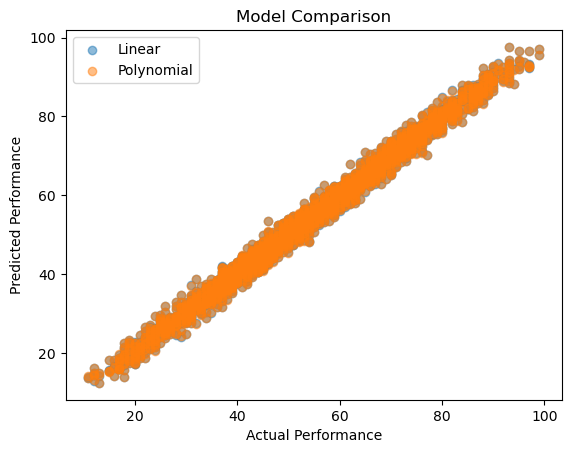

In [11]:
plt.scatter(y_test, y_pred_linear, label="Linear", alpha=0.5)
plt.scatter(y_test, y_pred_poly, label="Polynomial", alpha=0.5)

plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.title("Model Comparison")
plt.legend()
plt.show()

In [12]:
hours = float(input("Hours Studied: "))
previous = float(input("Previous Scores: "))
activities = int(input("Activities (1 Yes / 0 No): "))
sleep = float(input("Sleep Hours: "))
papers = float(input("Question Papers Practiced: "))

sample = pd.DataFrame([{
    "hours": hours,
    "previous": previous,
    "activities": activities,
    "sleep": sleep,
    "papers": papers
}])

result = linear_model.predict(sample)

print("Predicted Performance Index:", round(result[0], 2))

Hours Studied:  12
Previous Scores:  99
Activities (1 Yes / 0 No):  1
Sleep Hours:  5
Question Papers Practiced:  20


Predicted Performance Index: 107.82
